In [1]:
# Standard Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split

# Global variables
import warnings
warnings.filterwarnings("ignore")

start_year = 1993

In [2]:
# Custom API
from sys import path

path.append('../')
from API.get_curr_year import curr_year
from API.eda.data_visualizations import get_yearly_base_rates, get_seed_pairs, format_plot
import API.fetch.data_fetch as fetch
from API.model.model_selection import get_cv_models
from API.model.model_evaluation import evaluate_cv_models, model_predictions, get_classification_report
from API.preprocess.feature_engineering import create_bracket_winners
from API.preprocess.data_integrity import season_team_to_coach_tourney_team_dict
from API.preprocess.data_clean import clean_basic_stats, clean_tourney_data
from API.preprocess.data_pipeline import dataset_pipeline, feature_pipeline, bracket_pipeline

# Data Fetching

## Examples

### Team Regular Season Stats

In [3]:
basic_stats_df = fetch.get_team_data(url=f"https://www.sports-reference.com/cbb/seasons/{curr_year}-school-stats.html",
                                     attrs={'id': 'basic_school_stats'})
basic_stats_df.head()

,Rk,School,G,W,L,W-L%,SRS,SOS,Unnamed: 8,W.1,...,FT,FTA,FT%,ORB,TRB,AST,STL,BLK,TOV,PF
0,1,Abilene Christian,32,16,16,.500,-5.84,-2.39,NaN,8,...,476,666,.715,355,1081,421,331,94,476,670
1,2,Air Force,32,4,28,.125,-8.07,3.65,NaN,1,...,363,572,.635,236,956,428,181,91,433,571
2,3,Akron NCAA,35,28,7,.800,3.22,-3.75,NaN,17,...,445,590,.754,414,1347,621,267,131,414,623
3,4,Alabama NCAA,37,28,9,.757,25.54,16.14,NaN,13,...,671,932,.720,459,1567,636,228,167,469,700
4,5,Alabama A&M,32,10,22,.313,-20.52,-9.93,NaN,6,...,490,738,.664,447,1172,432,266,131,513,687


In [4]:
adv_stats_df = fetch.get_team_data(url=f"https://www.sports-reference.com/cbb/seasons/{curr_year}-advanced-school-stats.html", 
                                   attrs={'id': 'adv_school_stats'})
adv_stats_df.head()

,Rk,School,G,W,L,W-L%,SRS,SOS,Unnamed: 8,W.1,...,3PAr,TS%,TRB%,AST%,STL%,BLK%,eFG%,TOV%,ORB%,FT/FGA
0,1,Abilene Christian,32,16,16,.500,-5.84,-2.39,NaN,8,...,.262,.523,50.1,51.4,14.4,8.5,.483,18.0,31.8,.258
1,2,Air Force,32,4,28,.125,-8.07,3.65,NaN,1,...,.485,.525,46.6,62.9,8.7,8.1,.501,18.7,22.7,.225
2,3,Akron NCAA,35,28,7,.800,3.22,-3.75,NaN,17,...,.459,.579,52.3,58.6,10.5,9.8,.552,14.0,32.7,.197
3,4,Alabama NCAA,37,28,9,.757,25.54,16.14,NaN,13,...,.466,.596,53.5,55.4,8.1,10.1,.566,14.3,33.7,.283
4,5,Alabama A&M,32,10,22,.313,-20.52,-9.93,NaN,6,...,.410,.504,49.5,54.3,11.2,11.5,.470,18.1,35.1,.249


### Coach & Team Performance

In [5]:
coaches_rankings_df = fetch.get_coach_rankings_data(curr_year)
coaches_rankings_df.head()

,Coach_Team,Conf,Top_25,MM,S16,F4,Champs
371,Abilene Christian,WAC,0,,,,
337,Air Force,MWC,0,1,,,
127,Akron,MAC,0,6,1,,
278,Alabama,SEC,1,8,4,1,
151,Alabama A&M,SWAC,0,,,,


### Tournament Game Data

In [6]:
hist_bracket_df = fetch.get_hist_bracket(curr_year)
hist_bracket_df.head()

,Year,Round,Seed,Team,Score,Seed.1,Team.1,Score.1
0,2025,Play-In,16,Mount St. Mary's,83,16,American,72
1,2025,Play-In,11,UNC,95,11,San Diego State,68
2,2025,Play-In,16,Saint Francis (PA),68,16,Alabama State,70
3,2025,Play-In,11,Xavier,86,11,Texas,80
4,2025,First Round,1,Duke,93,16,Mount St. Mary's,49


# Data Pipeline

In [7]:
# Check if the historical data CSV exists, if it doesn't then create it
try:
    mm_matchups_df = pd.read_csv(f'{curr_year}_march_madness_hist_data.csv')
except FileNotFoundError:
    mm_matchups_df = dataset_pipeline(np.arange(start_year, curr_year))
    mm_matchups_df.to_csv(f'{curr_year}_march_madness_hist_data.csv', index=False)

mm_matchups_df

,Year,Round,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Underdog_Upset,G_Favorite,W-L%_Favorite,SRS_Favorite,...,eFG%_Underdog,TOV%_Underdog,ORB%_Underdog,FT/FGA_Underdog,Conf_Underdog,Top_25_Underdog,MM_Underdog,S16_Underdog,F4_Underdog,Champs_Underdog
0,1993,First Round,1,UNC,16,East Carolina,0,38,0.895,29.04,...,0.465,17.3,NaN,0.248,CAA,0,1,0,0,0
1,1993,First Round,8,Rhode Island,9,Purdue,0,30,0.633,9.50,...,0.519,18.8,NaN,0.278,Big Ten,1,10,1,0,0
2,1993,First Round,5,St. John's (NY),12,Texas Tech,0,30,0.633,13.14,...,0.530,18.1,NaN,0.304,SWC,0,1,0,0,0
3,1993,First Round,4,Arkansas,13,Holy Cross,0,31,0.710,17.72,...,0.516,16.8,NaN,0.336,Patriot,0,3,0,0,0
4,1993,First Round,6,Virginia,11,Manhattan,0,31,0.677,14.60,...,0.511,19.8,NaN,0.291,MAAC,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2004,2024,Sweet Sixteen,2,Arizona,6,Clemson,1,36,0.750,24.54,...,0.539,13.0,27.2,0.240,ACC,1,7,2,0,0
2005,2024,Elite Eight,4,Alabama,6,Clemson,0,37,0.676,20.69,...,0.539,13.0,27.2,0.240,ACC,1,7,2,0,0
2006,2024,Final Four,1,UConn,4,Alabama,0,40,0.925,26.70,...,0.563,13.6,35.0,0.273,SEC,1,7,3,1,0
2007,2024,Final Four,1,Purdue,11,NC State,0,39,0.872,24.93,...,0.507,12.1,28.1,0.234,ACC,1,5,1,1,0


## Handling Missing Values

### Finding the Nulls

In [8]:
# Given that a feature has any nulls, find the number of nulls present
true_nulls = fetch.get_feature_null_counts(mm_matchups_df)
true_nulls

Pace_Favorite    765
STL%_Favorite    765
ORB%_Favorite    765
ORtg_Favorite    765
ORtg_Underdog    764
STL%_Underdog    764
Pace_Underdog    764
ORB%_Underdog    763
ORB_Underdog     255
ORB_Favorite     254
TOV%_Underdog      3
TOV_Underdog       3
TOV_Favorite       1
TOV%_Favorite      1
dtype: int64

In [9]:
# Get turnover features from true_nulls
tov_null_fills = [col for col in true_nulls.index if ('TOV' in col)]

# All other features found in true_nulls are dropped from our original dataset
null_drops = list(set(true_nulls.index) - set(tov_null_fills))
mm_matchups_df.drop(null_drops, axis=1, inplace=True)

In [10]:
# View the rows containing all of the dataset's nulls to be imputed
# This will be a useful reference to validate the proper imputation of the nulls
tov_nulls_rows = fetch.get_null_rows(tov_null_fills, mm_matchups_df)
display(tov_nulls_rows)

,Year,TOV%_Underdog,TOV_Underdog,TOV_Favorite,TOV%_Favorite,Underdog_Upset
47,1993,NaN,NaN,373.0,15.9,1
54,1993,16.6,552.0,NaN,NaN,0
57,1993,NaN,NaN,561.0,17.4,0
470,2000,NaN,NaN,520.0,17.8,0


### What are the Distributions of the Features We Wish to Impute?

1993 feature distributions
2000 feature distributions


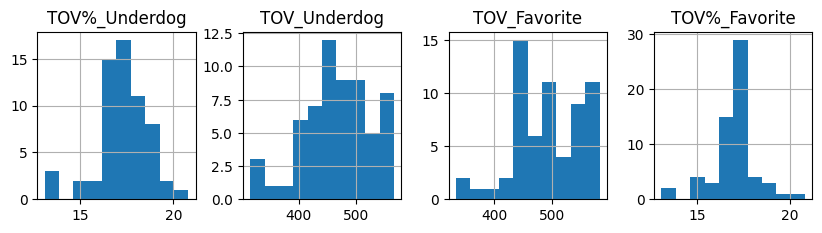

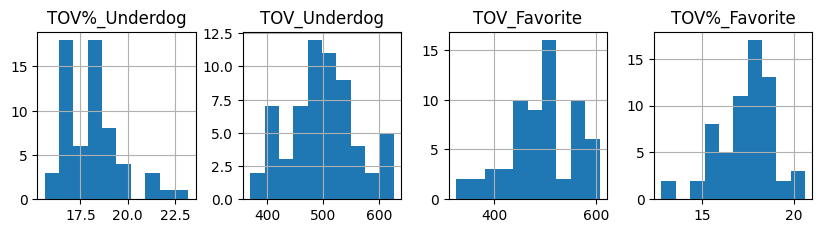

In [11]:
# View the distributions of the dataset's turnover features
tov_null_years = sorted(list(set(tov_nulls_rows['Year'])))

for year in tov_null_years:
    print(f"{year} feature distributions")
    year_df = mm_matchups_df[mm_matchups_df['Year'] == year]
    year_df[tov_null_fills].hist(figsize=(10, 5), layout=(len(tov_null_years), len(tov_null_fills)))

### Impute TOV Nulls by Season & Target Variable

In [12]:
# Retrieve TOV feature means by season; only include seasons that contain nulls
tov_col_means = mm_matchups_df[tov_nulls_rows.columns].groupby(['Year', 'Underdog_Upset']).mean()
tov_col_means.loc[tov_null_years]

TOV%_Underdog  TOV_Underdog  TOV_Favorite  TOV%_Favorite
Year Underdog_Upset                                                          
1993 0                   17.360000    463.044444    496.666667      16.984444
     1                   17.056250    475.937500    481.941176      17.282353
2000 0                   18.336364    492.704545    507.733333      17.511111
     1                   17.544444    511.000000    468.944444      17.066667

In [13]:
for year in tov_null_years:
    for label in [0, 1]:
        for col in tov_null_fills:
            # Get feature's rows with nulls for given year & label type
            fill_condition = (tov_nulls_rows['Year'] == year) & (tov_nulls_rows['Underdog_Upset'] == label)
            col_fill_rows = tov_nulls_rows[fill_condition].index
            # Get feature's mean for given year
            col_year_mean = np.round(tov_col_means.loc[(year, label), col], 1)
            # Impute nulls of interest
            mm_matchups_df.loc[col_fill_rows, col] = mm_matchups_df.loc[col_fill_rows, col].fillna(col_year_mean)

# Display rows that originally had nulls to see if they match discovered feature means
mm_matchups_df.loc[tov_nulls_rows.index, tov_null_fills]

,TOV%_Underdog,TOV_Underdog,TOV_Favorite,TOV%_Favorite
47,17.1,475.9,373.0,15.9
54,16.6,552.0,496.7,17.0
57,17.4,463.0,561.0,17.4
470,18.3,492.7,520.0,17.8


# Exploratory Data Analysis (EDA)

## What is our Bracket's Accuracy if We Guess the Favorite Always Wins?

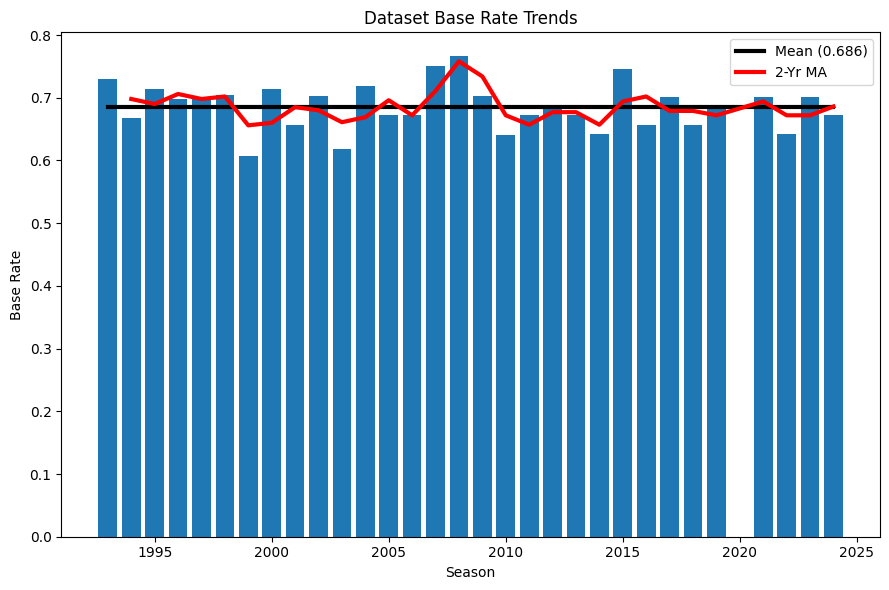

In [14]:
# Each season's base rate
yearly_base_rates = get_yearly_base_rates(mm_matchups_df)
# Dataset's mean base rate
mean_base_rate = np.round(yearly_base_rates.mean(), 3)
# Moving average
years_ma = 2
base_rate_ma = np.round(yearly_base_rates.rolling(years_ma).mean(), 3)

# Plot findings
plt.figure(figsize=(9, 6))

plt.plot(yearly_base_rates.index, [mean_base_rate] * len(yearly_base_rates), color='k', linewidth=3, label=f'Mean ({mean_base_rate})')
plt.plot(yearly_base_rates.index, base_rate_ma, color='r', linewidth=3, label=f'{years_ma}-Yr MA')
plt.bar(yearly_base_rates.index, yearly_base_rates)

format_plot(title='Dataset Base Rate Trends', xlabel='Season', ylabel='Base Rate')

## How Often Do Upsets Occur in a Given Year's March Madness?

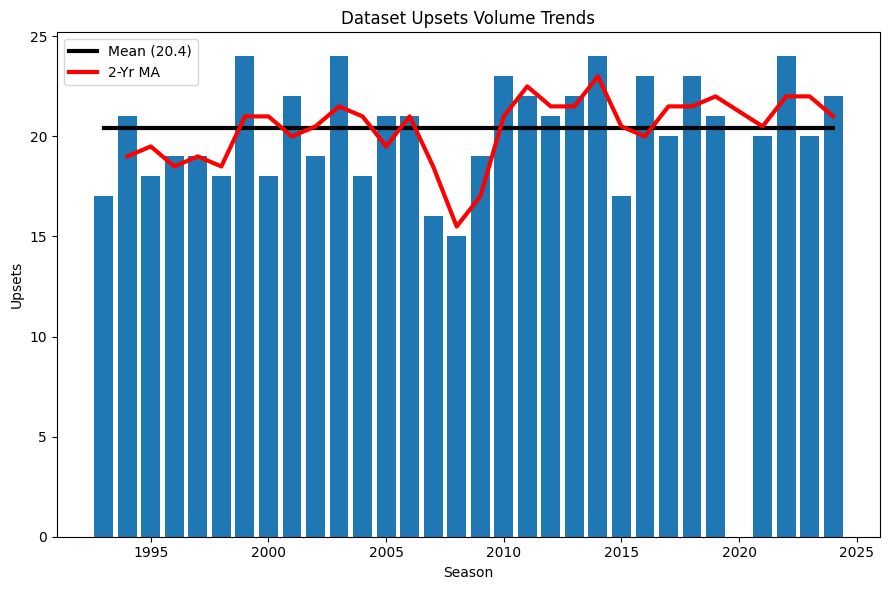

In [15]:
# Each season's upset count
yearly_upsets = mm_matchups_df.groupby('Year').agg({'Underdog_Upset': 'sum'})
# Dataset's mean upset count
mean_upsets = np.round(yearly_upsets['Underdog_Upset'].mean(), 1)
# Moving average
upsets_ma = np.round(yearly_upsets.rolling(years_ma).mean(), 1)

# Plot findings
plt.figure(figsize=(9, 6))

plt.plot(yearly_upsets.index, [mean_upsets] * len(yearly_upsets), color='k', linewidth=3, label=f'Mean ({mean_upsets})')
plt.plot(yearly_upsets.index, upsets_ma, color='r', linewidth=3, label=f'{years_ma}-Yr MA')
plt.bar(yearly_upsets.index, yearly_upsets['Underdog_Upset'])

format_plot(title='Dataset Upsets Volume Trends', xlabel='Season', ylabel='Upsets')

## What is the Distribution of Upsets Across the Tournament Rounds?

In [16]:
# Retrieve data about March Madness matchup seed pairings
seed_pairs = get_seed_pairs(mm_matchups_df)
# Extract seed pairs that resulted in upsets
upset_pairs = seed_pairs[seed_pairs['Underdog_Upset'] == 1]

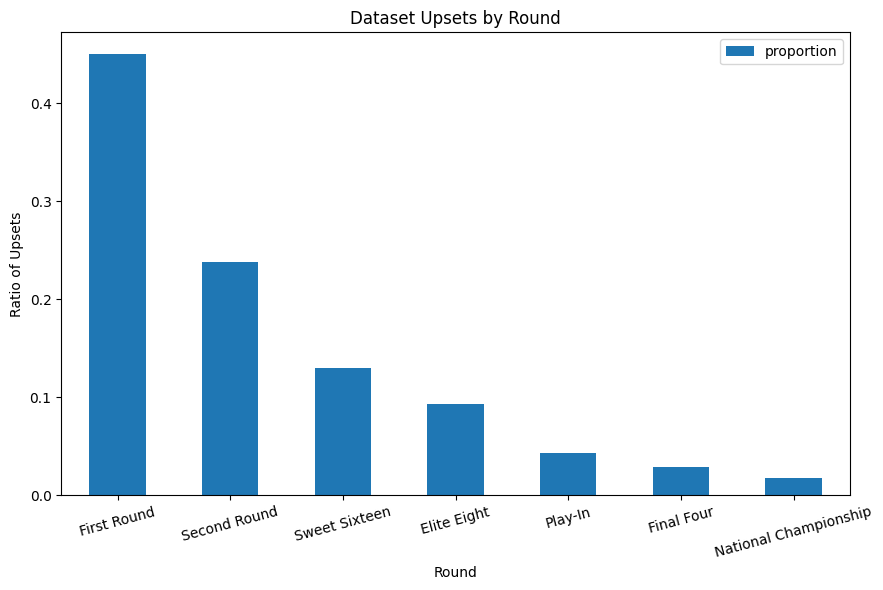

In [17]:
# Group upset seed pairs by round and count them
upset_rounds_freq = upset_pairs['Round'].value_counts(normalize=True)

# Plot findings
upset_rounds_freq.plot(figsize=(9, 6), kind='bar', rot=15)

format_plot(title='Dataset Upsets by Round', xlabel='Round', ylabel='Ratio of Upsets')

## Which Seeding Combinations are the Most Likely to Produce Upsets?

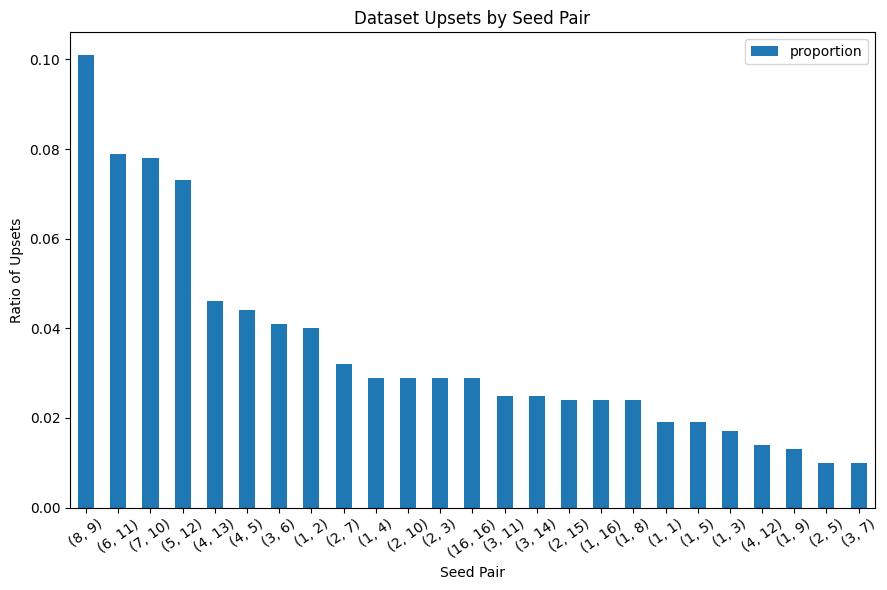

In [18]:
# Group upsets by seed pairing and count them
upset_pairs_freq = np.round(upset_pairs['Pairs'].value_counts(normalize=True)[:25], 3)

# Plot findings
upset_pairs_freq.plot(figsize=(9, 6), kind='bar', rot=35)

format_plot(title='Dataset Upsets by Seed Pair', xlabel='Seed Pair', ylabel='Ratio of Upsets')

# Feature Engineering & Analysis

In [19]:
# Drop unneeded features
mm_matchups_df.drop(['Year', 'Team_Favorite', 'Team_Underdog'], axis=1, inplace=True)
# Store rounds data (for EDA visualizations)
all_rounds = mm_matchups_df['Round']

# Create feature matrix and target variable
X = mm_matchups_df.drop('Underdog_Upset', axis=1)
y = mm_matchups_df['Underdog_Upset']

display(X), display(y)

,Round,Seed_Favorite,Seed_Underdog,G_Favorite,W-L%_Favorite,SRS_Favorite,FG_Favorite,FG%_Favorite,3P_Favorite,3P%_Favorite,...,BLK%_Underdog,eFG%_Underdog,TOV%_Underdog,FT/FGA_Underdog,Conf_Underdog,Top_25_Underdog,MM_Underdog,S16_Underdog,F4_Underdog,Champs_Underdog
0,First Round,1,16,38,0.895,29.04,1219,0.506,168,0.372,...,5.9,0.465,17.3,0.248,CAA,0,1,0,0,0
1,First Round,8,9,30,0.633,9.50,787,0.439,161,0.335,...,5.3,0.519,18.8,0.278,Big Ten,1,10,1,0,0
2,First Round,5,12,30,0.633,13.14,825,0.481,80,0.331,...,5.6,0.530,18.1,0.304,SWC,0,1,0,0,0
3,First Round,4,13,31,0.710,17.72,995,0.488,210,0.395,...,5.9,0.516,16.8,0.336,Patriot,0,3,0,0,0
4,First Round,6,11,31,0.677,14.60,847,0.441,140,0.334,...,6.2,0.511,19.8,0.291,MAAC,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2004,Sweet Sixteen,2,6,36,0.750,24.54,1124,0.484,284,0.366,...,10.9,0.539,13.0,0.240,ACC,1,7,2,0,0
2005,Elite Eight,4,6,37,0.676,20.69,1136,0.476,413,0.373,...,10.9,0.539,13.0,0.240,ACC,1,7,2,0,0
2006,Final Four,1,4,40,0.925,26.70,1177,0.497,340,0.358,...,11.0,0.563,13.6,0.273,SEC,1,7,3,1,0
2007,Final Four,1,11,39,0.872,24.93,1109,0.488,318,0.404,...,9.7,0.507,12.1,0.234,ACC,1,5,1,1,0


0       0
1       0
2       0
3       0
4       0
       ..
2004    1
2005    0
2006    0
2007    0
2008    0
Name: Underdog_Upset, Length: 2009, dtype: int64

(None, None)

In [20]:
"""We'll stratify the 80-20 split of our training & test datasets according to the target
variable's distribution so our model can learn the trends observed in our EDA"""
# Drop round data because it's already stored in previous notebook cell
X.drop('Round', axis=1, inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, 
                                                    stratify=pd.concat([y, all_rounds], axis=1))

# All datasets will be scaled based on fit found for training dataset
basic_stats_cols = clean_basic_stats(basic_stats_df).columns
data_cuts = {    
    'FULL': X,
    'TRAIN': X_train,
    'TEST': X_test,
}

# Pass datasets through feature pipeline to prep them for model fitting
prep_X_train = feature_pipeline('TRAIN', data_cuts, basic_stats_cols)
prep_X_test = feature_pipeline('TEST', data_cuts, basic_stats_cols)

prep_all_X = pd.concat([prep_X_train, prep_X_test])
prep_all_X

,Seed_Favorite,Seed_Underdog,Underdog_Rel_AST/Game,Underdog_Rel_3PAr,Underdog_Rel_FT/FGA,Underdog_Rel_AST%,Underdog_Rel_F4,Underdog_Rel_Top_25,Underdog_Rel_FT/Game,Underdog_Rel_TOV%,...,Underdog_Rel_FTr,Underdog_Rel_Champs,Underdog_Rel_3P/Game,Underdog_Rel_S16,Underdog_Rel_TRB/Game,Underdog_Rel_TS%,Underdog_Rel_TOV/Game,Underdog_Rel_FT%,Conf_Favorite,Conf_Underdog
64,1.372335,-0.256579,1.164253,-0.733935,0.484656,1.020637,0.418168,1.151965,0.753196,-1.413120,...,0.655655,0.374523,-0.071206,0.686286,0.685378,0.163512,-1.090177,-0.251305,25.0,7.0
418,-0.302185,-1.529178,-0.807588,0.151702,0.087863,-0.896010,0.761198,1.151965,-0.235651,0.410620,...,0.671471,0.374523,0.038715,0.515247,-0.825826,0.345292,0.178902,-1.340893,7.0,10.0
1023,-0.637089,-0.765619,0.158212,-1.162915,-0.831027,-0.123630,-2.669101,-0.825821,-0.806139,-0.010243,...,-0.419873,-2.595171,-1.335304,-1.537226,0.977014,-0.593907,0.032470,-1.114752,3.0,5.0
898,-0.971993,-2.038218,-1.089279,1.217234,-0.371582,0.191043,-0.953952,1.151965,-1.642856,1.252346,...,-0.451506,-0.615375,0.423441,-1.024108,-1.515148,0.860337,-0.309205,0.098186,3.0,7.0
1169,-0.637089,-0.765619,0.520387,-0.484849,1.361779,0.934817,0.418168,-0.825821,1.171555,1.112058,...,1.383217,-1.605273,-0.620814,0.515247,0.287693,0.042325,1.155116,0.324327,28.0,28.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1332,-0.637089,-0.002059,1.445945,1.660053,-0.141860,0.863301,-0.267892,-0.825821,0.410903,0.831483,...,-0.356606,0.374523,2.127224,-0.510990,1.003527,1.133008,1.301548,0.591584,9.0,5.0
1767,-0.637089,1.270541,0.278937,-1.176753,-0.016556,0.233954,-0.267892,-0.825821,-0.197618,1.158821,...,0.370956,0.374523,-1.445225,-0.339950,-1.223512,-0.018269,0.959873,-1.114752,2.0,15.0
245,-0.637089,-0.002059,-1.129521,-0.000517,0.380237,-0.409697,-0.267892,-0.825821,-0.159585,0.036520,...,-0.056091,0.374523,0.148637,-0.339950,-1.170487,-0.169752,-0.553259,0.982191,6.0,40.0
42,-0.971993,-1.274658,-0.928313,-1.910171,0.818798,-0.495517,-0.267892,1.151965,0.220740,-0.150531,...,0.544939,0.374523,-2.159715,0.173168,-0.534190,0.163512,-0.846123,0.817725,28.0,3.0


### What are the Distributions of all our Features?

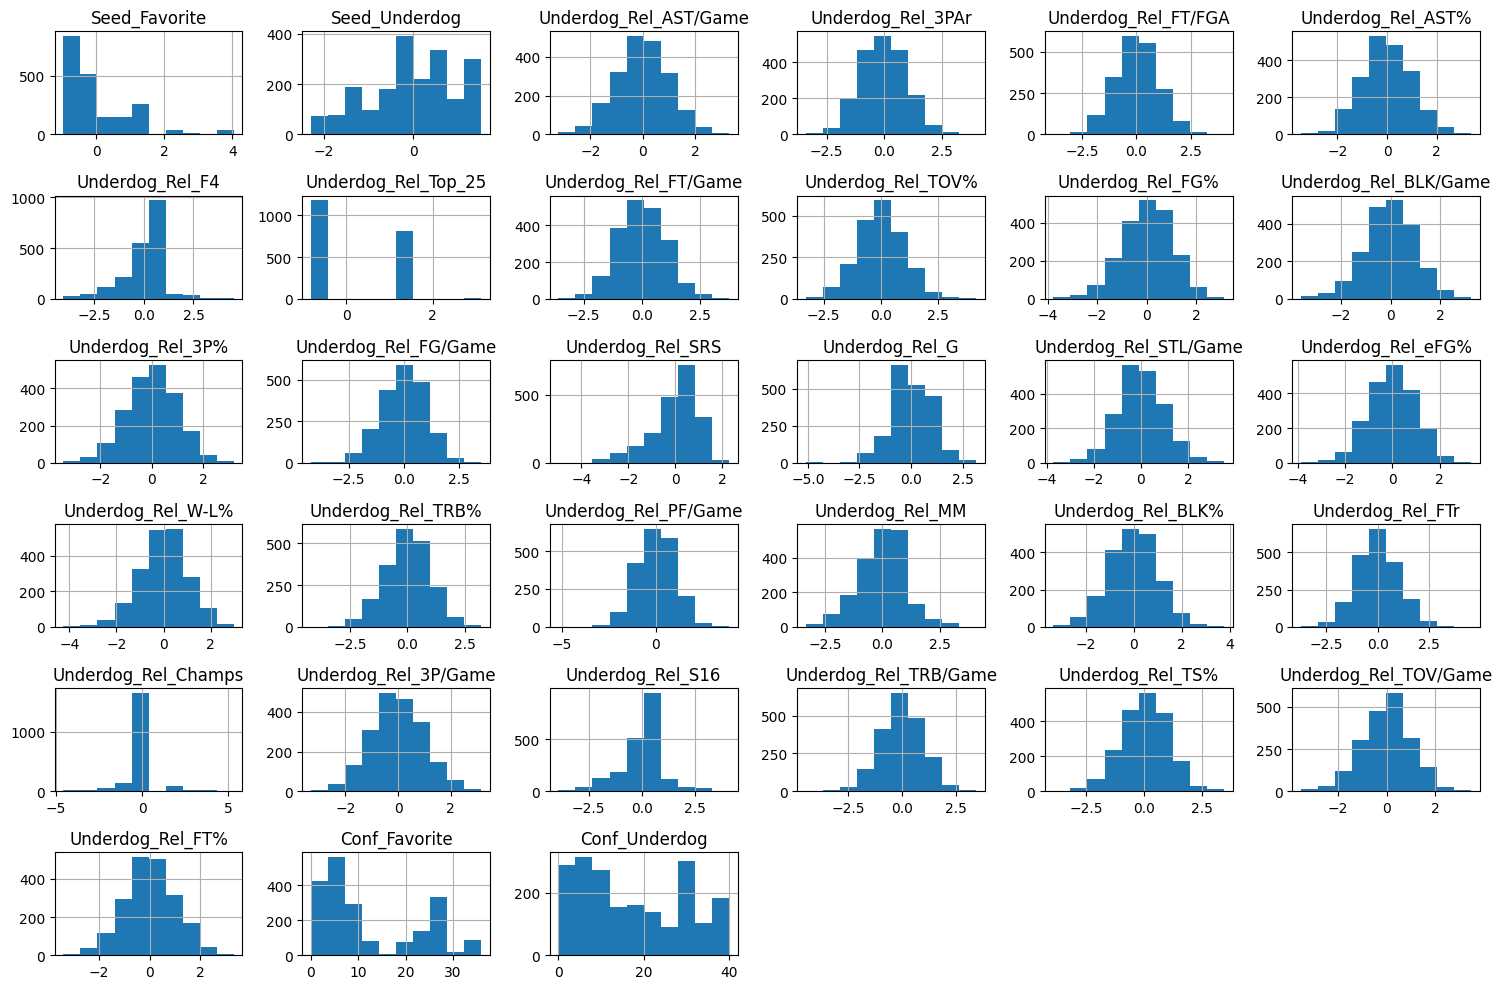

In [21]:
prep_all_X.hist(figsize=(15, 10))
plt.tight_layout()

### What Features have the Greatest Predictive Power?

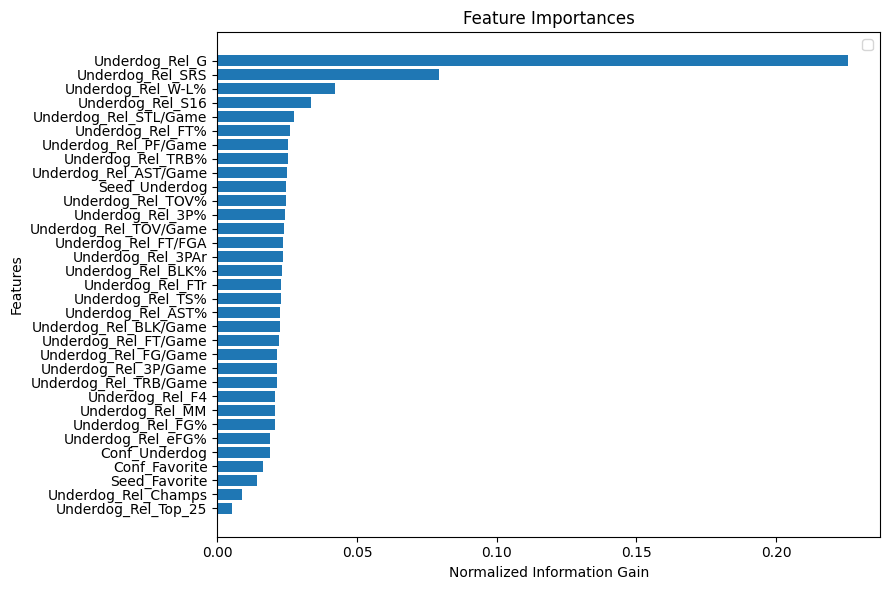

In [22]:
# Fit data to a Random Forest to find feature importances
rf = RandomForestClassifier().fit(prep_X_train, y_train)

# Sort features & their corresponding values in by importance
importances = rf.feature_importances_
feat_importances = prep_all_X.columns[np.argsort(importances)]
feat_values = np.sort(importances)

# Plot findings
plt.figure(figsize=(9, 6))
plt.barh(feat_importances, feat_values)

format_plot(title='Feature Importances', xlabel='Normalized Information Gain', ylabel='Features')

### What are the Correlations Between Features?

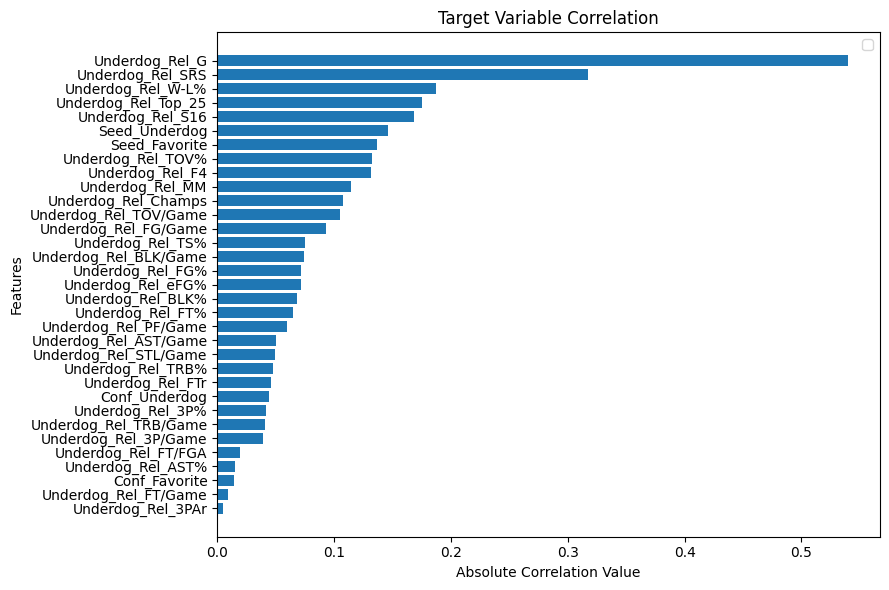

In [23]:
# Get feature matrix's correlations to target variable, then sort by absolute value
prep_X_y = prep_X_train.merge(y_train, left_index=True, right_index=True)
abs_desc_corr = np.abs(prep_X_y.corr().loc['Underdog_Upset']).sort_values()
abs_desc_corr.drop('Underdog_Upset', inplace=True)

# Plot findings
plt.figure(figsize=(9, 6))
plt.barh(abs_desc_corr.index, abs_desc_corr.values)

format_plot(title='Target Variable Correlation', xlabel='Absolute Correlation Value', ylabel='Features')

# Model Selection

### Cross-Validation

In [24]:
%%time

# Perform CV on chosen models with the training set, then assess their respective performances
cv_models = get_cv_models(y)
model_performance = evaluate_cv_models(cv_models, prep_X_train, y_train)
     
model_performance

CPU times: total: 31.4 s
Wall time: 41.2 s


,Best_Mean_Accuracy,Best_Mean_Accuracy_Std
Naive Bayes,0.727,0.016
LogReg,0.820,0.010
SVM,0.814,0.015
Random Forest,0.814,0.009
XGBoost,0.820,0.021


In [25]:
# Identify best model to use
selected_model = 'XGBoost'
best_model = cv_models[selected_model][-1].best_estimator_

best_params = cv_models[selected_model][-1].best_params_
display(best_params)

{'n_estimators': np.int64(35),
 'learning_rate': 0.1,
 'subsample': np.float64(0.5),
 'tree_method': 'gpu_hist',
 'sampling_method': 'gradient_based',
 'lambda': 100,
 'eval_metric': 'error',
 'verbosity': 0,
 'seed': 42}

# Model Evaluation

In [26]:
# Concatenate all visualization data into a single DataFrame
test_game_data = pd.concat([y_test, all_rounds, mm_matchups_df[['Seed_Favorite', 'Seed_Underdog']]], 
                           join='inner', axis=1).drop('Underdog_Upset', axis=1)

# Overwrite the actual target variable (used for the join) with the best model's predictions
y_preds = model_predictions(best_model, prep_X_test)
test_game_data['Underdog_Upset'] = y_preds

# Get seed pairs data
test_seed_pairs = get_seed_pairs(test_game_data)
# Extract seed pairs that resulted in upsets
test_upset_pairs = test_seed_pairs[test_seed_pairs['Underdog_Upset'] == 1]

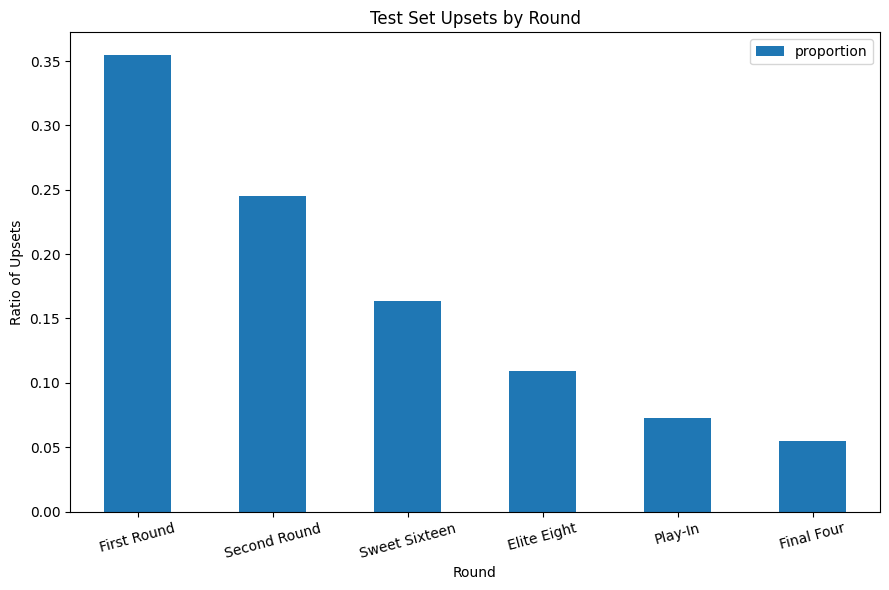

In [27]:
# Group upset seed pairs by round and count them
test_upset_rounds_freq = test_upset_pairs['Round'].value_counts(normalize=True)

# Plot findings
test_upset_rounds_freq.plot(figsize=(9, 6), kind='bar', rot=15)

format_plot(title='Test Set Upsets by Round', xlabel='Round', ylabel='Ratio of Upsets')

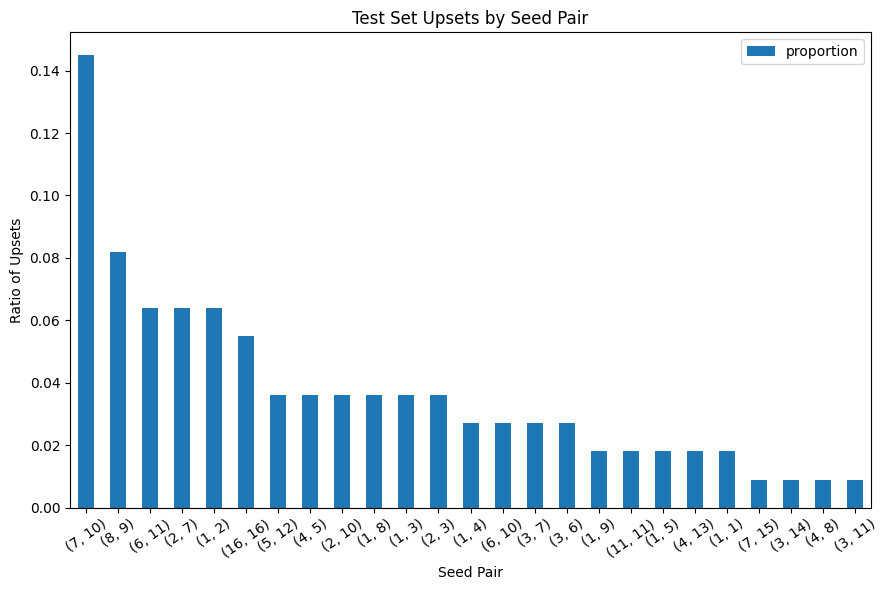

In [28]:
# Group upsets by seed pairing and count them
test_upset_pairs_freq = np.round(test_upset_pairs['Pairs'].value_counts(normalize=True)[:25], 3)

# Plot findings
test_upset_pairs_freq.plot(figsize=(9, 6), kind='bar', rot=35)

format_plot(title='Test Set Upsets by Seed Pair', xlabel='Seed Pair', ylabel='Ratio of Upsets')

In [29]:
# Show confusion matrix for model's test set predictions
test_set_report = get_classification_report(y_test, y_preds)
print("Test Set Metrics Report \n\n", test_set_report)

Test Set Metrics Report 

               precision    recall  f1-score   support

           0       0.83      0.87      0.85       276
           1       0.68      0.60      0.64       126

    accuracy                           0.79       402
   macro avg       0.75      0.73      0.74       402
weighted avg       0.78      0.79      0.78       402



# 2026 March Madness Predictions

## Data Pipeline

In [30]:
# Check if the starting bracket CSV exists, if it doesn't then create it
try:
    curr_bracket_df = pd.read_csv(f'{curr_year}_march_madness_curr_start_bracket.csv')
except FileNotFoundError:
    curr_bracket_df = fetch.get_current_bracket()
    curr_bracket_df.to_csv(f'{curr_year}_march_madness_curr_start_bracket.csv', index=False)
    raise SystemExit("Manually add First Four matchups to starting bracket before resuming program execution")

# Extract play-in matchups
play_in = curr_bracket_df[:4]

# Extract first round matchups
first_round = curr_bracket_df[4:]
first_round.index = range(len(first_round))

display(play_in), display(first_round)

,Seed,Team,Seed.1,Team.1
0,16,Mount St. Mary's,16,American
1,11,Xavier,11,Texas
2,16,Saint Francis (PA),16,Alabama State
3,11,UNC,11,San Diego State


,Seed,Team,Seed.1,Team.1
0,1,Duke,0,NaN
1,8,Mississippi State,9,Baylor
2,5,Oregon,12,Liberty
3,4,Arizona,13,Akron
4,6,BYU,11,VCU
5,3,Wisconsin,14,Montana
6,7,Saint Mary's,10,Vanderbilt
7,2,Alabama,15,Robert Morris
8,1,Houston,16,SIU-Edwardsville
9,8,Gonzaga,9,Georgia


(None, None)

In [31]:
# Check if bracket predictions have already been generated, otherwise create them
try:
    bracket_preds = pd.read_csv(f'{curr_year}_march_madness_bracket_predictions.csv')
except FileNotFoundError:
    bracket_preds = bracket_pipeline(curr_year, play_in, first_round, best_model, data_cuts, null_drops)
    bracket_preds.to_csv(f'{curr_year}_march_madness_bracket_predictions.csv', index=False)

# Display bracket_pipeline() predictions by round
for _round in bracket_preds['Round'].unique():
    display(bracket_preds[bracket_preds['Round'] == _round])

,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Round,Underdog_Upset,Winner
0,16,Mount St. Mary's,16,American,Play-In,0,Mount St. Mary's
1,11,Xavier,11,Texas,Play-In,1,Texas
2,16,Alabama State,16,Saint Francis (PA),Play-In,0,Alabama State
3,11,San Diego State,11,UNC,Play-In,1,UNC


,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Round,Underdog_Upset,Winner
4,1,Duke,16,Mount St. Mary's,First Round,0,Duke
5,8,Mississippi State,9,Baylor,First Round,1,Baylor
6,5,Oregon,12,Liberty,First Round,0,Oregon
7,4,Arizona,13,Akron,First Round,0,Arizona
8,6,BYU,11,VCU,First Round,0,BYU
9,3,Wisconsin,14,Montana,First Round,0,Wisconsin
10,7,Saint Mary's,10,Vanderbilt,First Round,0,Saint Mary's
11,2,Alabama,15,Robert Morris,First Round,0,Alabama
12,1,Houston,16,SIU-Edwardsville,First Round,0,Houston
13,8,Gonzaga,9,Georgia,First Round,0,Gonzaga


,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Round,Underdog_Upset,Winner
36,1,Duke,9,Baylor,Second Round,0,Duke
37,4,Arizona,5,Oregon,Second Round,0,Arizona
38,3,Wisconsin,6,BYU,Second Round,0,Wisconsin
39,2,Alabama,7,Saint Mary's,Second Round,0,Alabama
40,1,Houston,8,Gonzaga,Second Round,0,Houston
41,4,Purdue,5,Clemson,Second Round,0,Purdue
42,3,Kentucky,6,Illinois,Second Round,0,Kentucky
43,2,Tennessee,7,UCLA,Second Round,0,Tennessee
44,1,Auburn,9,Creighton,Second Round,0,Auburn
45,4,Texas A&M,5,Michigan,Second Round,1,Michigan


,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Round,Underdog_Upset,Winner
52,1,Duke,4,Arizona,Sweet Sixteen,0,Duke
53,2,Alabama,3,Wisconsin,Sweet Sixteen,1,Wisconsin
54,1,Houston,4,Purdue,Sweet Sixteen,0,Houston
55,2,Tennessee,3,Kentucky,Sweet Sixteen,0,Tennessee
56,1,Auburn,5,Michigan,Sweet Sixteen,0,Auburn
57,2,Michigan State,11,UNC,Sweet Sixteen,0,Michigan State
58,1,Florida,4,Maryland,Sweet Sixteen,0,Florida
59,2,St. John's (NY),3,Texas Tech,Sweet Sixteen,1,Texas Tech


,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Round,Underdog_Upset,Winner
60,1,Duke,3,Wisconsin,Elite Eight,0,Duke
61,1,Houston,2,Tennessee,Elite Eight,0,Houston
62,1,Auburn,2,Michigan State,Elite Eight,0,Auburn
63,1,Florida,3,Texas Tech,Elite Eight,0,Florida


,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Round,Underdog_Upset,Winner
64,1,Duke,1,Houston,Final Four,1,Houston
65,1,Florida,1,Auburn,Final Four,0,Florida


,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Round,Underdog_Upset,Winner
66,1,Florida,1,Houston,National Championship,1,Houston


## Pre-Tournament Model Evaluation (3/19/25)

In [32]:
# Get seed pairs data
curr_seed_pairs = get_seed_pairs(bracket_preds)
# Extract seed pairs that resulted in upsets
curr_upset_pairs = curr_seed_pairs[curr_seed_pairs['Underdog_Upset'] == 1]

Total Upsets: 13


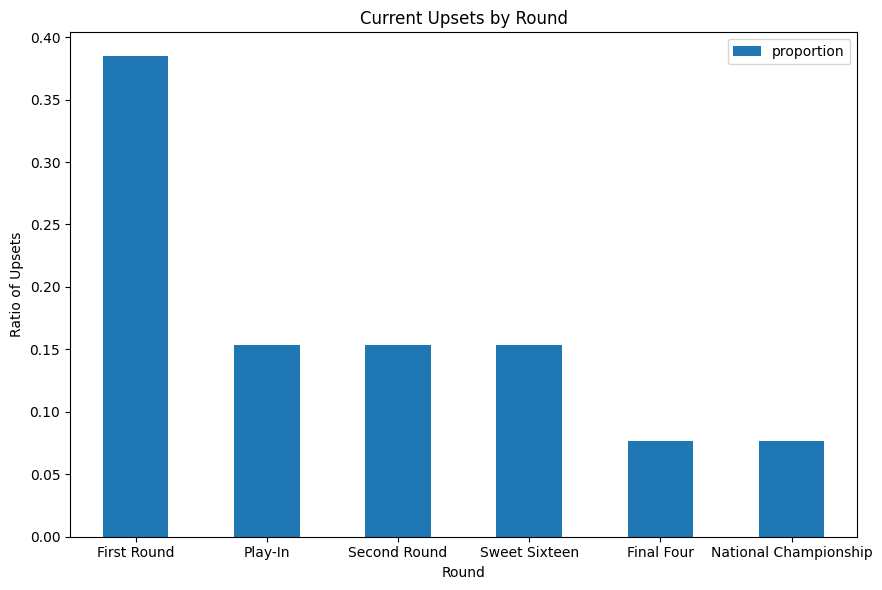

In [33]:
# Group upset seed pairs by round and count them
curr_upset_rounds_freq = curr_upset_pairs['Round'].value_counts(normalize=True)

# Plot findings
curr_upset_rounds_freq.plot(figsize=(9, 6), kind='bar', rot=0)

format_plot(title='Current Upsets by Round', xlabel='Round', ylabel='Ratio of Upsets')
print(f"Total Upsets: {len(curr_upset_pairs)}")

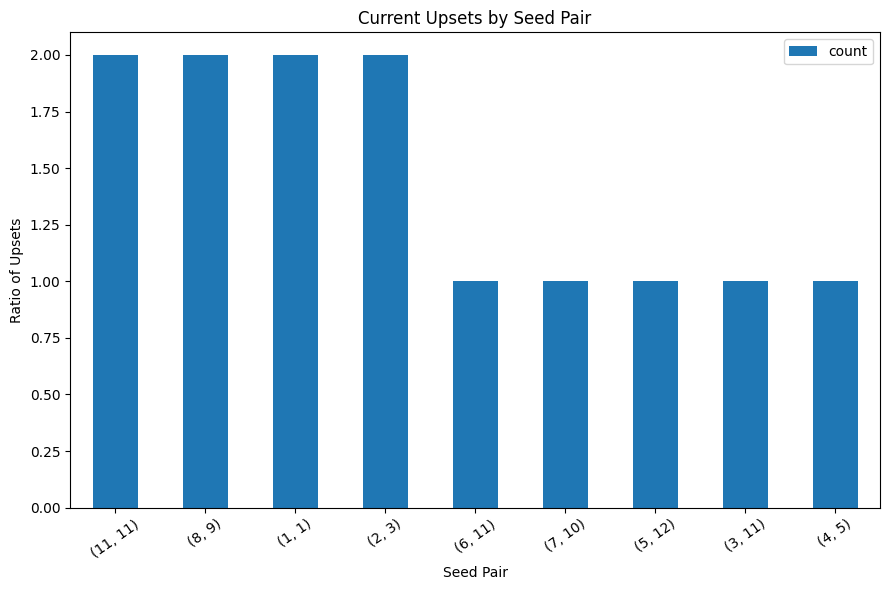

In [34]:
# Group upsets by seed pairing and count them
curr_upset_pairs_freq = curr_upset_pairs['Pairs'].value_counts()

# Plot findings
curr_upset_pairs_freq.plot(figsize=(9, 6), kind='bar', rot=35)

format_plot(title='Current Upsets by Seed Pair', xlabel='Seed Pair', ylabel='Ratio of Upsets')

## Post-Tournament Model Evaluation (3/6/26)

### True Tournament Outcomes EDA

In [35]:
basic_stats_df = fetch.get_team_data(url=f"https://www.sports-reference.com/cbb/seasons/men/{curr_year}-school-stats.html",
                                     attrs={'id': 'basic_school_stats'})
clean_basic_stats_df = clean_basic_stats(basic_stats_df)

# Clean basic stats' school names to properly merge with raw tournament data
if clean_basic_stats_df['School'].str.contains('NCAA').any():
    clean_basic_stats_df['School'] = clean_basic_stats_df['School'].apply(lambda school: school[:-5])

clean_basic_stats_df['School'].replace(season_team_to_coach_tourney_team_dict, inplace=True)

# Create DataFrame (data integrity intact) with all March Madness outcomes
bracket_trues = clean_tourney_data(hist_bracket_df, clean_basic_stats_df)
bracket_trues['Team_Favorite'].replace(season_team_to_coach_tourney_team_dict, inplace=True)
bracket_trues['Team_Underdog'].replace(season_team_to_coach_tourney_team_dict, inplace=True)

create_bracket_winners(bracket_trues)

# Display true tournament results by round
for _round in bracket_trues['Round'].unique():
    display(bracket_trues[bracket_trues['Round'] == _round])

,Year,Round,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Underdog_Upset,Winner
0,2025,Play-In,16,Mount St. Mary's,16,American,0,Mount St. Mary's
1,2025,Play-In,11,San Diego State,11,UNC,1,UNC
2,2025,Play-In,16,Alabama State,16,Saint Francis (PA),0,Alabama State
3,2025,Play-In,11,Xavier,11,Texas,0,Xavier


,Year,Round,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Underdog_Upset,Winner
4,2025,First Round,1,Duke,16,Mount St. Mary's,0,Duke
5,2025,First Round,8,Mississippi State,9,Baylor,1,Baylor
6,2025,First Round,5,Oregon,12,Liberty,0,Oregon
7,2025,First Round,4,Arizona,13,Akron,0,Arizona
8,2025,First Round,6,BYU,11,VCU,0,BYU
9,2025,First Round,3,Wisconsin,14,Montana,0,Wisconsin
10,2025,First Round,7,Saint Mary's,10,Vanderbilt,0,Saint Mary's
11,2025,First Round,2,Alabama,15,Robert Morris,0,Alabama
19,2025,First Round,1,Houston,16,SIU-Edwardsville,0,Houston
20,2025,First Round,8,Gonzaga,9,Georgia,0,Gonzaga


,Year,Round,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Underdog_Upset,Winner
12,2025,Second Round,1,Duke,9,Baylor,0,Duke
13,2025,Second Round,4,Arizona,5,Oregon,0,Arizona
14,2025,Second Round,3,Wisconsin,6,BYU,1,BYU
15,2025,Second Round,2,Alabama,7,Saint Mary's,0,Alabama
27,2025,Second Round,1,Houston,8,Gonzaga,0,Houston
28,2025,Second Round,4,Purdue,12,McNeese State,0,Purdue
29,2025,Second Round,3,Kentucky,6,Illinois,0,Kentucky
30,2025,Second Round,2,Tennessee,7,UCLA,0,Tennessee
42,2025,Second Round,1,Auburn,9,Creighton,0,Auburn
43,2025,Second Round,4,Texas A&M,5,Michigan,1,Michigan


,Year,Round,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Underdog_Upset,Winner
16,2025,Sweet Sixteen,1,Duke,4,Arizona,1,Arizona
17,2025,Sweet Sixteen,2,Alabama,6,BYU,1,BYU
31,2025,Sweet Sixteen,1,Houston,4,Purdue,0,Houston
32,2025,Sweet Sixteen,2,Tennessee,3,Kentucky,0,Tennessee
46,2025,Sweet Sixteen,1,Auburn,5,Michigan,0,Auburn
47,2025,Sweet Sixteen,2,Michigan State,6,Ole Miss,0,Michigan State
61,2025,Sweet Sixteen,1,Florida,4,Maryland,0,Florida
62,2025,Sweet Sixteen,3,Texas Tech,10,Arkansas,0,Texas Tech


,Year,Round,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Underdog_Upset,Winner
18,2025,Elite Eight,1,Duke,2,Alabama,0,Duke
33,2025,Elite Eight,1,Houston,2,Tennessee,0,Houston
48,2025,Elite Eight,1,Auburn,2,Michigan State,0,Auburn
63,2025,Elite Eight,1,Florida,3,Texas Tech,0,Florida


,Year,Round,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Underdog_Upset,Winner
64,2025,Final Four,1,Duke,1,Houston,1,Houston
65,2025,Final Four,1,Florida,1,Auburn,0,Florida


,Year,Round,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Underdog_Upset,Winner
66,2025,National Championship,1,Florida,1,Houston,0,Florida


In [36]:
# Get seed pairs data
true_seed_pairs = get_seed_pairs(bracket_trues)
# Extract seed pairs that resulted in upsets
true_upset_pairs = true_seed_pairs[true_seed_pairs['Underdog_Upset'] == 1]

Total Upsets: 15


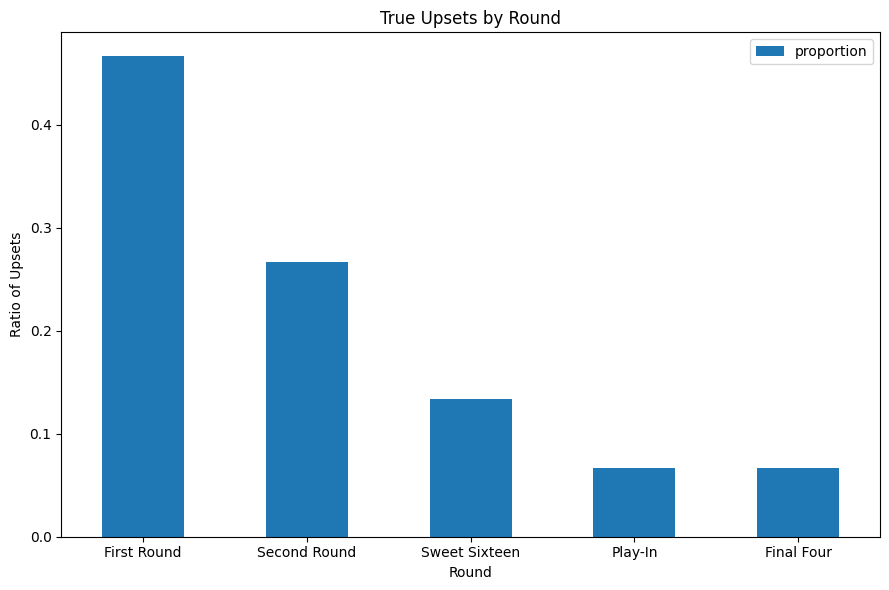

In [37]:
# Group upset seed pairs by round and count them
true_upset_rounds_freq = true_upset_pairs['Round'].value_counts(normalize=True)

# Plot findings
true_upset_rounds_freq.plot(figsize=(9, 6), kind='bar', rot=0)

format_plot(title='True Upsets by Round', xlabel='Round', ylabel='Ratio of Upsets')
print(f"Total Upsets: {len(true_upset_pairs)}")

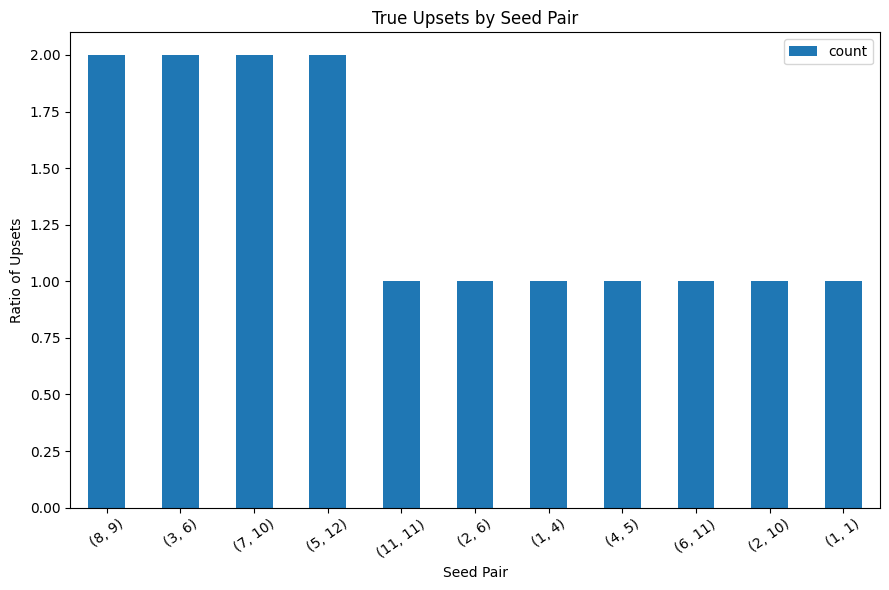

In [38]:
# Group upsets by seed pairing and count them
true_upset_pairs_freq = true_upset_pairs['Pairs'].value_counts()

# Plot findings
true_upset_pairs_freq.plot(figsize=(9, 6), kind='bar', rot=35)

format_plot(title='True Upsets by Seed Pair', xlabel='Seed Pair', ylabel='Ratio of Upsets')

### Compare Predicitons to True Outcomes

In [39]:
# Display correct predictions by round
correct_preds_df = pd.DataFrame(columns=['# Correct Preds', '# Possible Preds'])

for _round in bracket_trues['Round'].unique():
    # Extract round data from predictions & trues
    trues_round = bracket_trues[bracket_trues['Round'] == _round]
    preds_round = bracket_preds[bracket_preds['Round'] == _round]
    
    # Intersection of predictions & trues indicates the model's correct picks
    correct_preds = set(trues_round['Winner']).intersection(set(preds_round['Winner']))
    
    # Input data into Dataframe
    correct_preds_df.loc[_round] = [len(correct_preds), len(preds_round)]
    
correct_preds_df.loc['Tournament Total'] = [correct_preds_df['# Correct Preds'].sum(), correct_preds_df['# Possible Preds'].sum()]
correct_preds_df

,# Correct Preds,# Possible Preds
Play-In,3,4
First Round,28,32
Second Round,13,16
Sweet Sixteen,6,8
Elite Eight,4,4
Final Four,2,2
National Championship,0,1
Tournament Total,56,67


In [40]:
# Calculate and output the model's accuracy
tourney_totals = correct_preds_df.loc['Tournament Total']
print(f"Accuracy: {np.round(tourney_totals['# Correct Preds'] / tourney_totals['# Possible Preds'], 3)}")

Accuracy: 0.836
